## Logistic Regression Realization

This is a demo for how to write a logistic regression with gradient descent and newton's method

For hw you could easily build with sklearn built-in function or write your own one.

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
#create the class
class LogisticRegression():
    def __init__(self, lr = 0.001) -> None:  # intialization
        self.lr = lr
        self.weight = None
        self.bias = None

    def sigmoid(self, x):  
        # TODO 1: Implement the sigmoid squashing function
        # Hint: use np.exp()    
        return 1/(1+np.exp(-x))

    def fit(self, X, y, n_iters = 1000):
        try:
            n_samples, n_features = X.shape
        except:  # situation for only one attr 
            n_samples = X.shape
            n_samples = n_samples[0]
            X = np.asarray(X).reshape(-1,1)
            n_features = 1
        self.weight = np.zeros(n_features)
        # you could always try to add the bias but we're skipping it for this experiment. 
        # self.bias = 0  
        acc = []  # record accuracy 
        for i in range(n_iters):
            # TODO 2: Calculate the linear combination and pass it through sigmoid
            linear_pred = np.dot(X, self.weight)
            pred = self.sigmoid(linear_pred)
            print(pred.shape, y.shape)

            # TODO 3: Update weights using the Gradient Descent formula
            self.weight = self.weight - self.lr*(1/n_samples) * np.dot(X.T, (pred - y))
            # self.bias = self.bias - self.lr*(1/n_samples) * np.sum(pred-y)
            acc.append(np.sum(pred==y)/len(y))
        return acc
    
    def fitNewtwon(self, X, y, n_iters = 100):  # using netwon's function 
        try:
            n_samples, n_features = X.shape
        except:
            n_samples = X.shape
            n_samples = n_samples[0]
            X = np.asarray(X).reshape(-1,1)
            n_features = 1
        self.weight = np.zeros(n_features)
        acc = []
        for i in range(n_iters):
            temp = self.sigmoid(np.dot(X, self.weight))
            # Newton's method start here
            gradient = X.T.dot(temp-y) # First order derivative
            E = np.eye(n_samples) # Identity matrix on size n_samples
            
            # TODO 4: Populate the diagonal matrix E (The core of the Hessian)
            # Hint: The derivative of sigmoid is h * (1 - h)
            for j in range(n_samples):
                h = self.sigmoid(X[j].dot(self.weight))
                E[j,j] = h * (1-h) #second-order derivative
            
            Hessian = X.T.dot(E).dot(X)
            
            # TODO 5: Calculate the Newton step and update the weights
            # Hint: Use np.linalg.solve for the matrix inversion
            d_theta = np.linalg.solve(Hessian,gradient) + 0.1*self.weight
            self.weight = self.weight - d_theta

            acc.append(np.sum(temp==y)/len(y))
        return acc

    def predict(self, X):
        try:
            n_samples,_ = X.shape
        except:
            n_samples = X.shape
            n_samples = n_samples[0]
            X = np.asarray(X).reshape(-1,1)
        linear_pred = np.dot(X, self.weight) #+ self.bias
        pred = self.sigmoid(linear_pred)
        class_pred = [0 if y<=0.5 else 1 for y in pred]
        return class_pred

In [3]:
from sklearn.linear_model import LinearRegression

x = np.array([3, 7, 6, 8, 5]).reshape(-1, 1)
y = np.array([0,1,0,1,1]).reshape(-1, 1)
lr = LinearRegression(fit_intercept=False)
lr.fit(x,y)
print(lr.coef_)

[[0.10928962]]


## single attribute
Here we tried single attribute from diabetes dataset

In [4]:
df = pd.read_csv('diabetes.csv')
y = df['Outcome']
# X = df.drop(columns=['Outcome'])
X = df['Insulin'] #Single feature for experiment
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [18]:
lr = LogisticRegression()
lr.fit(X_train, y_train, 1000)
y_pred = lr.predict(X_test)
acc = np.sum(y_pred==y_test)/len(y_test)
print("The accuracy is: ", acc)

(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,) (455,)
(455,)

/var/folders/r9/09k6jqg120g_wwpl6kqsccsh0000gn/T/ipykernel_88891/998443538.py:11: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


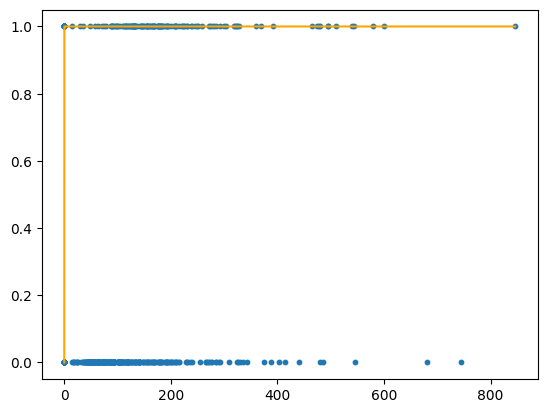

In [6]:
x_val = np.arange(min(X), max(X), 0.01)
y_val = lr.predict(x_val)
plt.scatter(X, y, s=10)
plt.plot(x_val, y_val, color='orange')
plt.show()

## multi attrs and comparison with newton's method
This part is using breast cancer data set from sklearn.

lr2 is gradient descent and lr3 is newtons method.

In [7]:
bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [8]:
print(bc.data.shape)
print(bc.target.shape)

(569, 30)
(569,)


The test acc of gd is: 0.8947368421052632


/var/folders/r9/09k6jqg120g_wwpl6kqsccsh0000gn/T/ipykernel_89811/2662341680.py:11: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


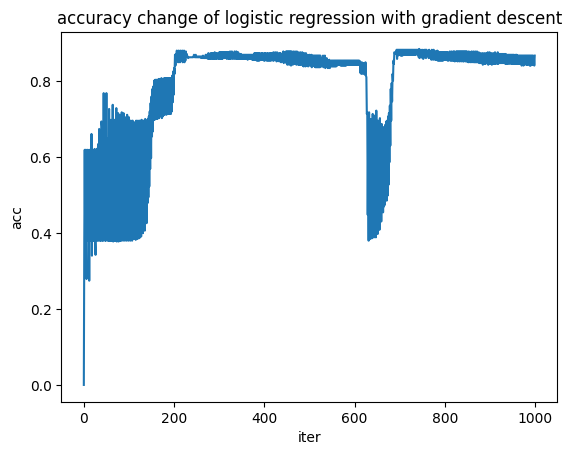

In [9]:
lr2 = LogisticRegression(lr = 0.01)
acc_gd = lr2.fit(X_train, y_train, 1000)
plt.plot(acc_gd)
plt.title("accuracy change of logistic regression with gradient descent")
plt.xlabel("iter")
plt.ylabel("acc")
y_pred = lr2.predict(X_test)
acc = np.sum(y_pred==y_test)/len(y_test)
print("The test acc of gd is:", acc)

/var/folders/r9/09k6jqg120g_wwpl6kqsccsh0000gn/T/ipykernel_88891/2662341680.py:11: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


The test acc of Newton is: 0.9824561403508771


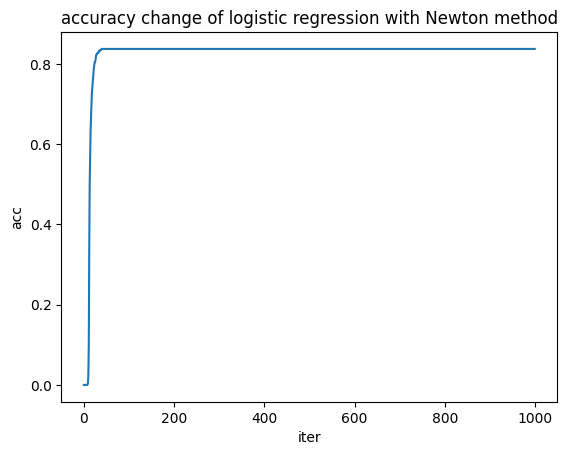

In [16]:
lr3 = LogisticRegression(lr = 0.01)
acc_nt = lr3.fitNewtwon(X_train, y_train, 1000)
plt.plot(acc_nt)
plt.title("accuracy change of logistic regression with Newton method")
plt.xlabel("iter")
plt.ylabel("acc")
y_pred = lr3.predict(X_test)
acc = np.sum(y_pred==y_test)/len(y_test)
print("The test acc of Newton is:", acc)